# Eksplorasi Data

Eksplorasi data memeriksa karakteristik dataset sebelum masuk ke pemodelan. Dataset yang digunakan terdiri dari tiga file CSV hasil crawling Sentinel-5P via OpenEO, masing-masing berisi konsentrasi harian NO2, CO, dan SO2 di wilayah Kamal-Kampus UTM selama periode Agustus 2025 hingga Agustus 2026. Tahap ini mencakup pemeriksaan struktur data, distribusi statistik, pola missing value, deteksi outlier, pola musiman, tren jangka panjang, dan korelasi antar polutan.

---

## Instalasi & Import Library

In [1]:
!pip install pandas matplotlib seaborn -q


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

print(f"pandas     : {pd.__version__}")
print(f"matplotlib : {plt.matplotlib.__version__}")
print(f"seaborn    : {sns.__version__}")

pandas     : 2.3.3
matplotlib : 3.10.8
seaborn    : 0.13.2


---

## Load Data

Tiga file CSV dimuat secara terpisah lalu digabung ke satu dataframe berdasarkan kolom `date` menggunakan outer join. Outer join dipilih agar hari yang hanya memiliki sebagian polutan tetap masuk — tidak ada baris yang dibuang hanya karena satu polutan missing. Kolom `feature_index` dihapus karena hanya berisi indeks geometri AOI dari OpenEO, bukan informasi polutan.

In [3]:
df_no2 = pd.read_csv("NO2_KAMAL-UTM.csv")
df_co  = pd.read_csv("CO_KAMAL-UTM.csv")
df_so2 = pd.read_csv("SO2_KAMAL-UTM.csv")

for df_pol in [df_no2, df_co, df_so2]:
    df_pol["date"] = pd.to_datetime(df_pol["date"])
    df_pol.drop(columns=["feature_index"], inplace=True)
    df_pol.sort_values("date", inplace=True)
    df_pol.reset_index(drop=True, inplace=True)

df = df_no2.merge(df_co, on="date", how="outer").merge(df_so2, on="date", how="outer")
df.sort_values("date", inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Total baris : {len(df)}")
print(f"Periode     : {df['date'].min().date()} s/d {df['date'].max().date()}")

Total baris : 370
Periode     : 2025-08-24 s/d 2026-08-28


---

## 1. Struktur dan Tipe Data

Sebelum analisis apapun dilakukan, perlu dipastikan bahwa setiap kolom terbaca dengan tipe data yang benar. Kolom `date` harus bertipe `datetime64` agar bisa dipakai untuk operasi temporal seperti resampling dan plotting time series. Kolom polutan harus bertipe `float64` agar fungsi statistik dan visualisasi berjalan tanpa error. Jika salah satu kolom terbaca sebagai `object` (string), seluruh perhitungan numerik akan gagal.

In [4]:
print("=== Shape ===")
print(f"Baris : {df.shape[0]}")
print(f"Kolom : {df.shape[1]}")
print()
print("=== Kolom & Tipe Data ===")
print(df.dtypes)

=== Shape ===
Baris : 370
Kolom : 4

=== Kolom & Tipe Data ===
date    datetime64[ns, UTC]
NO2                 float64
CO                  float64
SO2                 float64
dtype: object


Dataset memiliki 370 baris dan 4 kolom. Satu baris merepresentasikan satu hari pengamatan. Kolom `date` sudah bertipe `datetime64[ns]` dan ketiga kolom polutan bertipe `float64` — semua sesuai untuk analisis lanjutan.

In [5]:
print("=== Preview 10 Baris Pertama ===")
df.head(10)

=== Preview 10 Baris Pertama ===


,date,NO2,CO,SO2
0,2025-08-24 00:00:00+00:00,NaN,NaN,NaN
1,2025-08-25 00:00:00+00:00,0.000020,0.028240,0.000272
2,2025-08-26 00:00:00+00:00,0.000035,NaN,-0.002125
3,2025-08-27 00:00:00+00:00,0.000086,0.030417,0.000169
4,2025-08-28 00:00:00+00:00,0.000010,0.025137,0.000109
5,2025-08-29 00:00:00+00:00,0.000034,0.023990,-0.000365
6,2025-08-30 00:00:00+00:00,0.000026,0.028700,0.000124
7,2025-08-31 00:00:00+00:00,0.000025,0.027550,-0.000478
8,2025-09-01 00:00:00+00:00,0.000011,0.023669,0.000298
9,2025-09-02 00:00:00+00:00,0.000018,0.020387,-0.000132


In [6]:
print("=== Preview 10 Baris Terakhir ===")
df.tail(10)

=== Preview 10 Baris Terakhir ===


,date,NO2,CO,SO2
360,2026-08-19 00:00:00+00:00,1.128241e-05,0.024064,0.000579
361,2026-08-20 00:00:00+00:00,1.734417e-05,0.025629,0.000164
362,2026-08-21 00:00:00+00:00,2.488306e-05,0.025582,0.000383
363,2026-08-22 00:00:00+00:00,-8.041791e-07,0.033008,-0.000207
364,2026-08-23 00:00:00+00:00,1.517305e-05,0.035256,-0.000467
365,2026-08-24 00:00:00+00:00,3.042386e-05,0.029695,-0.000215
366,2026-08-25 00:00:00+00:00,2.706911e-05,0.030743,0.000132
367,2026-08-26 00:00:00+00:00,1.562199e-05,0.030572,0.000409
368,2026-08-27 00:00:00+00:00,4.311178e-05,0.034008,0.000109
369,2026-08-28 00:00:00+00:00,3.527338e-05,0.034731,-0.000111


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 370 entries, 0 to 369
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype              
---  ------  --------------  -----              
 0   date    370 non-null    datetime64[ns, UTC]
 1   NO2     194 non-null    float64            
 2   CO      202 non-null    float64            
 3   SO2     234 non-null    float64            
dtypes: datetime64[ns, UTC](1), float64(3)
memory usage: 11.7 KB


Output `info()` memperlihatkan jumlah data non-null per kolom. NO2 hanya memiliki 194 nilai valid dari 370 baris, CO 202, dan SO2 234. Perbedaan jumlah non-null ini mengindikasikan bahwa ketiga polutan tidak selalu missing di hari yang sama — ada hari di mana SO2 tersedia tapi NO2 tidak, atau sebaliknya. Pola ini akan dianalisis lebih dalam di seksi Missing Values.

---

## 2. Analisis Statistik Deskriptif

Statistik deskriptif merangkum distribusi nilai setiap polutan dalam satu tabel. Angka-angka ini memberi gambaran awal sebelum masuk ke visualisasi: seberapa besar nilainya, seberapa menyebar, dan apakah ada tanda-tanda distribusi yang tidak normal.

In [8]:
df[["NO2", "CO", "SO2"]].describe().T

,count,mean,std,min,25%,50%,75%,max
NO2,194.0,0.000035,0.000023,-0.000011,0.000020,0.000028,0.000043,0.000147
CO,202.0,0.028868,0.003832,0.020132,0.026199,0.029059,0.031217,0.044651
SO2,234.0,0.000064,0.000322,-0.002125,-0.000129,0.000064,0.000243,0.001092


Beberapa hal yang langsung terlihat dari tabel ini. CO memiliki nilai rata-rata 0.028868 mol/m², jauh lebih besar secara absolut dibanding NO2 (0.000035) dan SO2 (0.000064). Ini bukan berarti CO lebih berbahaya dalam proporsi yang sama — perbedaan ini mencerminkan perbedaan kelimpahan alami gas-gas ini di troposfer dan sensitivitas instrumen TROPOMI terhadap masing-masing gas. SO2 memiliki nilai minimum negatif (-0.002125), yang secara fisik tidak mungkin dan merupakan noise retrieval algoritma TROPOMI.

In [9]:
print("=== Mean vs Median ===")
for col in ["NO2", "CO", "SO2"]:
    mean    = df[col].mean()
    median  = df[col].median()
    selisih = abs(mean - median)
    skew    = df[col].skew()
    arah    = "right-skewed" if mean > median else "left-skewed"
    print(f"{col:4s}  mean: {mean:.6f}  median: {median:.6f}  selisih: {selisih:.6f}  skew: {skew:.4f}  -> {arah}")

=== Mean vs Median ===
NO2   mean: 0.000035  median: 0.000028  selisih: 0.000006  skew: 1.6735  -> right-skewed
CO    mean: 0.028868  median: 0.029059  selisih: 0.000191  skew: 0.2312  -> left-skewed
SO2   mean: 0.000064  median: 0.000064  selisih: 0.000000  skew: -1.0465  -> left-skewed


NO2 memiliki skewness 1.67 (right-skewed kuat): mean (0.000035) lebih besar dari median (0.000028), artinya ada beberapa hari dengan konsentrasi sangat tinggi yang menarik rata-rata ke atas. SO2 menunjukkan left-skewed (-1.05) akibat dominasi nilai negatif di ekor kiri distribusi. CO paling mendekati distribusi normal dengan skewness hanya 0.23.

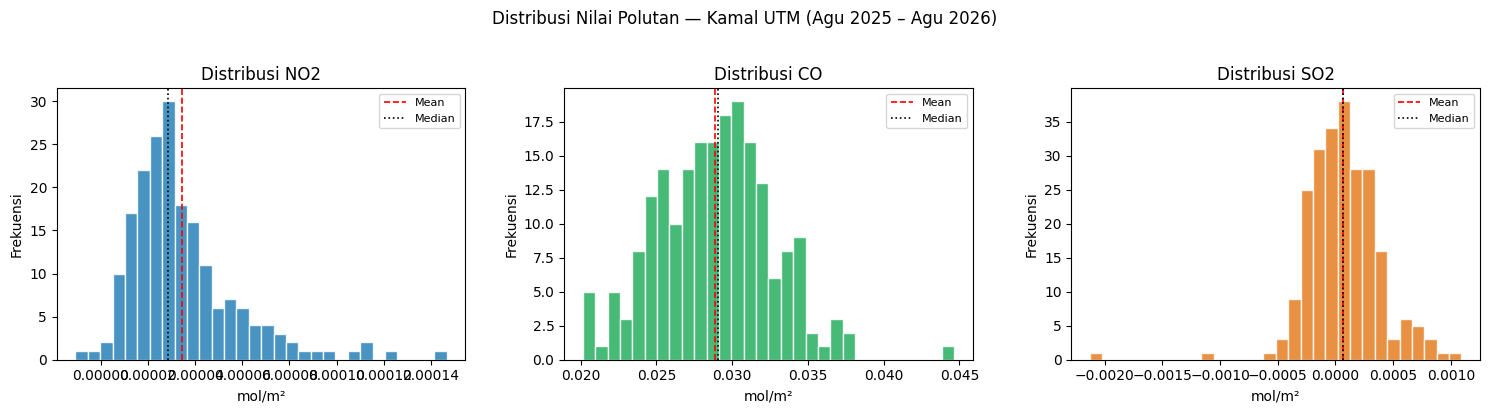

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, color in zip(axes, ["NO2", "CO", "SO2"], ["#2980b9", "#27ae60", "#e67e22"]):
    data = df[col].dropna()
    ax.hist(data, bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(),   color='red',   linestyle='--', linewidth=1.2, label='Mean')
    ax.axvline(data.median(), color='black', linestyle=':',  linewidth=1.2, label='Median')
    ax.set_title(f"Distribusi {col}")
    ax.set_xlabel("mol/m²")
    ax.set_ylabel("Frekuensi")
    ax.legend(fontsize=8)

plt.suptitle("Distribusi Nilai Polutan — Kamal UTM (Agu 2025 – Agu 2026)", y=1.02)
plt.tight_layout()
plt.show()

Histogram memperlihatkan karakter distribusi yang berbeda untuk setiap polutan. NO2 menumpuk di nilai rendah (0.00001-0.00004 mol/m²) dengan ekor panjang ke kanan — garis mean (merah putus-putus) berada di kanan median (hitam titik-titik), mengkonfirmasi right-skew. CO membentuk distribusi yang lebih simetris dan lebar, mencerminkan variasi harian yang lebih merata sepanjang tahun. SO2 memiliki distribusi yang menyebar ke kiri hingga masuk wilayah negatif, dengan mean dan median yang hampir berimpit karena nilai positif dan negatif saling menetralkan.

---

## 3. Missing Values

### Mengapa data lompat-lompat padahal di-set per hari?

Saat crawling, parameter `aggregate_temporal_period(period="day")` digunakan untuk meminta agregasi per hari. Tapi parameter ini hanya mengatur **cara agregasi data yang sudah masuk ke server** — bukan jaminan bahwa setiap hari akan ada data. Sentinel-5P tetap hanya menghasilkan pengukuran valid pada hari di mana dua kondisi terpenuhi sekaligus: orbit satelit melewati wilayah kajian, dan kondisi atmosfer memungkinkan pengukuran.

Ada dua penyebab utama hari-hari yang kosong:

**Tutupan awan (cloud cover).** TROPOMI mengukur radiasi elektromagnetik yang dipantulkan dari permukaan bumi. Awan tebal menyerap dan memantulkan sinyal sebelum mencapai sensor di ketinggian 824 km, sehingga pengukuran tidak valid dan OpenEO mengembalikan `NaN` untuk hari itu. Ini penyebab paling dominan, terutama di musim hujan (November-Maret) ketika awan konvektif tebal sering menutup wilayah Jawa Timur dan Madura. Data menunjukkan missing NO2 mencapai 27 hari di Januari 2026 dan 25 hari di Desember 2025 — keduanya puncak musim hujan.

**Gap orbit satelit.** Sentinel-5P mengorbit Bumi sekali sehari dengan swath lebar sekitar 2.600 km. Meski swath-nya lebar, bounding box Kamal-UTM yang hanya berukuran sekitar 3,6 x 4,8 km bisa jatuh di celah antar track orbit yang berdekatan pada hari-hari tertentu, sehingga tidak ada data yang terekam. Ini terjadi lebih jarang dibanding cloud cover tapi tetap berkontribusi pada hari-hari missing di musim kemarau.

Kombinasi dua faktor ini menghasilkan dataset dengan missing value yang tinggi: NO2 47,6%, CO 45,4%, dan SO2 36,8% dari total 370 hari. SO2 memiliki persentase missing paling kecil karena algoritma retrieval SO2 di TROPOMI dirancang lebih toleran terhadap awan tipis dibanding NO2 dan CO.

In [11]:
print("=== Jumlah Missing Value ===")
total = len(df)
for col in ["NO2", "CO", "SO2"]:
    jumlah = df[col].isnull().sum()
    persen = jumlah / total * 100
    print(f"{col:4s}  {jumlah:3d} hari missing  ({persen:.1f}% dari {total} hari)")

print()
semua_missing = df[["NO2","CO","SO2"]].isnull().all(axis=1).sum()
ada_semua     = (~df[["NO2","CO","SO2"]].isnull().any(axis=1)).sum()
print(f"Hari semua polutan missing sekaligus : {semua_missing} hari")
print(f"Hari ketiga polutan lengkap          : {ada_semua} hari")

=== Jumlah Missing Value ===
NO2   176 hari missing  (47.6% dari 370 hari)
CO    168 hari missing  (45.4% dari 370 hari)
SO2   136 hari missing  (36.8% dari 370 hari)

Hari semua polutan missing sekaligus : 115 hari
Hari ketiga polutan lengkap          : 158 hari


Dari 370 hari, hanya 158 hari di mana ketiga polutan tersedia lengkap. Sebanyak 115 hari semua polutan missing sekaligus — angka ini konsisten dengan penjelasan cloud cover di atas. Ketika awan menutup wilayah, semua instrumen TROPOMI terdampak bersamaan tanpa memandang jenis gas yang diukur. Streak missing terpanjang yang tercatat adalah 10 hari berturut-turut, kemungkinan besar bertepatan dengan periode hujan berkepanjangan atau La Niña yang memperkuat tutupan awan di Jawa Timur.

C:\Users\ARIEL\AppData\Local\Temp\ipykernel_17080\1895569373.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["bulan"] = df["date"].dt.to_period("M")


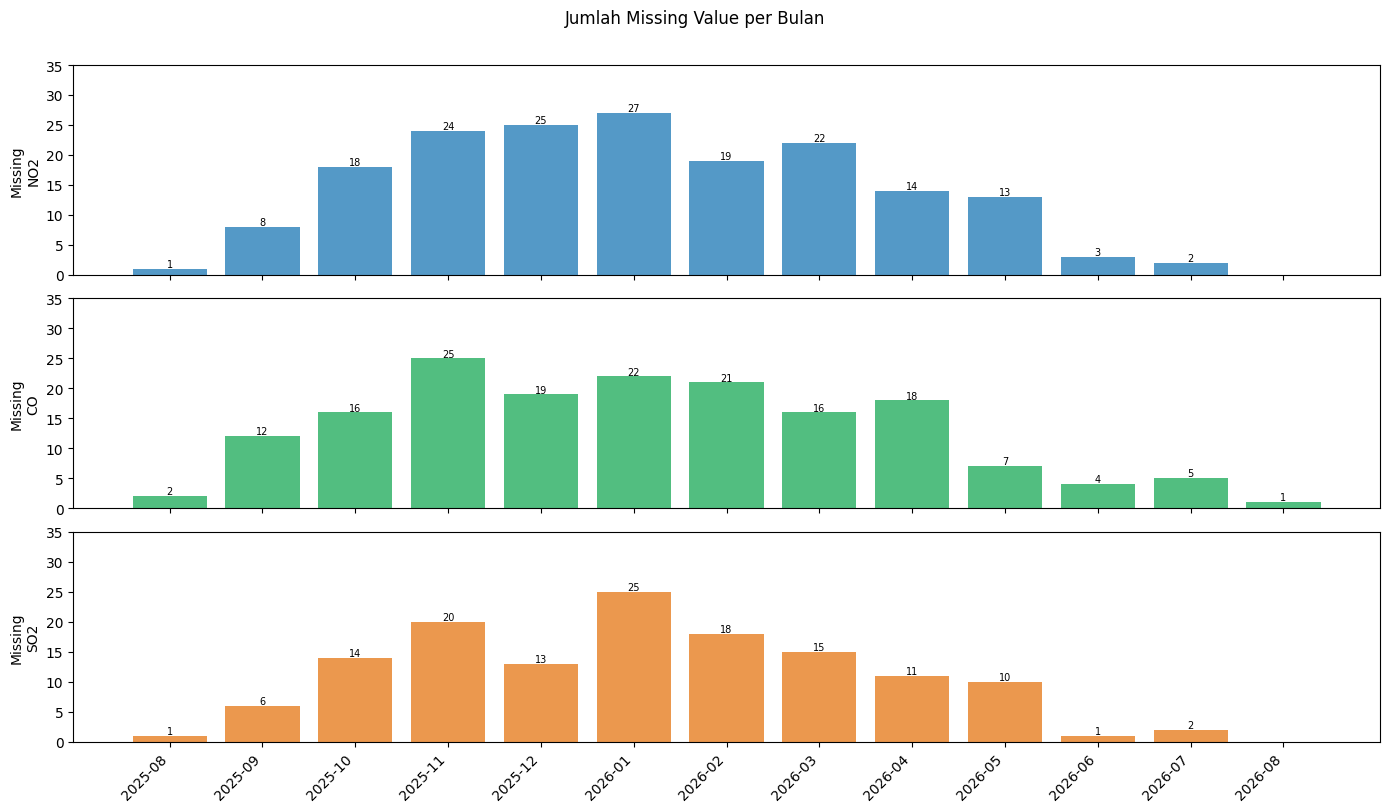

In [12]:
df["bulan"] = df["date"].dt.to_period("M")

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

for ax, col, color in zip(axes, ["NO2", "CO", "SO2"], ["#2980b9", "#27ae60", "#e67e22"]):
    miss = df.groupby("bulan")[col].apply(lambda x: x.isnull().sum())
    ax.bar(miss.index.astype(str), miss.values, color=color, alpha=0.8)
    ax.set_ylabel(f"Missing\n{col}")
    ax.set_ylim(0, 35)
    for i, v in enumerate(miss.values):
        if v > 0:
            ax.text(i, v + 0.3, str(v), ha='center', fontsize=7)

plt.xticks(rotation=45, ha='right')
plt.suptitle("Jumlah Missing Value per Bulan", y=1.01)
plt.tight_layout()
plt.show()

df.drop(columns=["bulan"], inplace=True)

Bar chart ini memperlihatkan pola musiman missing value yang jelas. Periode November 2025 hingga Maret 2026 (musim hujan) secara konsisten memiliki missing value tinggi di semua polutan — NO2 mencapai puncak 27 hari missing di Januari 2026, SO2 25 hari di Januari 2026. Sebaliknya, Juni dan Juli 2026 (pertengahan kemarau) hampir bersih dengan hanya 1-4 hari missing per bulan. Pola ini mengkonfirmasi bahwa tutupan awan musim hujan adalah faktor pengendali utama ketersediaan data.

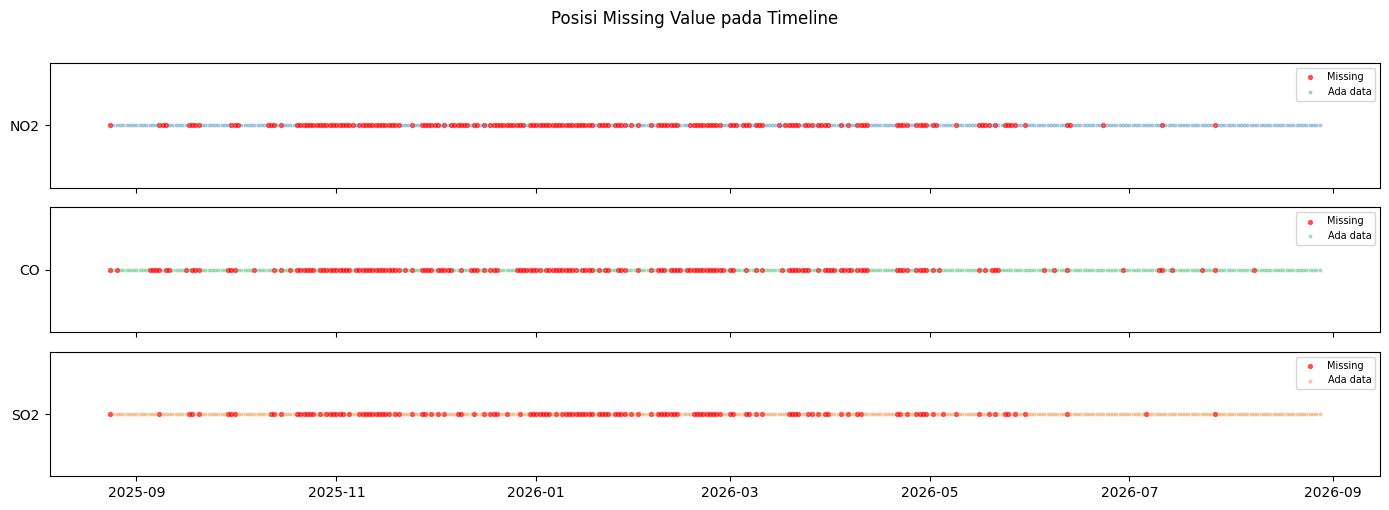

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(14, 5), sharex=True)

for ax, col, color in zip(axes, ["NO2", "CO", "SO2"], ["#2980b9", "#27ae60", "#e67e22"]):
    missing = df[col].isnull()
    ax.scatter(df.loc[missing,  "date"], [col] * missing.sum(),
               color='red', s=8, alpha=0.6, label='Missing')
    ax.scatter(df.loc[~missing, "date"], [col] * (~missing).sum(),
               color=color, s=4, alpha=0.3, label='Ada data')
    ax.set_yticks([col])
    ax.legend(fontsize=7, loc='upper right')

plt.suptitle("Posisi Missing Value pada Timeline", y=1.01)
plt.tight_layout()
plt.show()

Scatter timeline memperlihatkan distribusi spasial missing value sepanjang periode. Perhatikan bahwa titik merah (missing) pada ketiga baris sering muncul di rentang waktu yang sama — ini adalah tanda bahwa awan menutup wilayah dan memengaruhi semua polutan sekaligus. Bagian kiri plot (Agustus-Oktober 2025) dan kanan (Juni-Agustus 2026) terlihat lebih banyak titik berwarna (ada data), sedangkan bagian tengah (November 2025-Maret 2026) didominasi titik merah, sesuai dengan pola musim hujan yang teridentifikasi sebelumnya.

---

## 4. Deteksi Outlier

Outlier dideteksi menggunakan metode IQR. Nilai yang berada di luar rentang `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]` diklasifikasikan sebagai outlier. Pada data polutan satelit, outlier bisa bermakna dua hal yang sangat berbeda: kejadian polusi ekstrem yang nyata seperti kebakaran besar atau aktivitas industri mendadak, atau artefak pengukuran satelit seperti interferensi awan tipis yang tidak terfilter sempurna. Keduanya perlu diidentifikasi sebelum pemodelan agar tidak menghasilkan model yang terpengaruh nilai ekstrem yang tidak representatif.

In [14]:
print("=== Deteksi Outlier (Metode IQR) ===\n")

for col in ["NO2", "CO", "SO2"]:
    data  = df[col].dropna()
    Q1    = data.quantile(0.25)
    Q3    = data.quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    out_bawah = data[data < lower]
    out_atas  = data[data > upper]
    negatif   = data[data < 0]

    print(f"--- {col} ---")
    print(f"  Q1              : {Q1:.6f}")
    print(f"  Q3              : {Q3:.6f}")
    print(f"  IQR             : {IQR:.6f}")
    print(f"  Batas bawah IQR : {lower:.6f}")
    print(f"  Batas atas IQR  : {upper:.6f}")
    print(f"  Outlier bawah   : {len(out_bawah)} data")
    print(f"  Outlier atas    : {len(out_atas)} data")
    print(f"  Nilai negatif   : {len(negatif)} data")
    print()

=== Deteksi Outlier (Metode IQR) ===

--- NO2 ---
  Q1              : 0.000020
  Q3              : 0.000043
  IQR             : 0.000023
  Batas bawah IQR : -0.000014
  Batas atas IQR  : 0.000077
  Outlier bawah   : 0 data
  Outlier atas    : 11 data
  Nilai negatif   : 2 data

--- CO ---
  Q1              : 0.026199
  Q3              : 0.031217
  IQR             : 0.005018
  Batas bawah IQR : 0.018673
  Batas atas IQR  : 0.038743
  Outlier bawah   : 0 data
  Outlier atas    : 1 data
  Nilai negatif   : 0 data

--- SO2 ---
  Q1              : -0.000129
  Q3              : 0.000243
  IQR             : 0.000371
  Batas bawah IQR : -0.000685
  Batas atas IQR  : 0.000799
  Outlier bawah   : 2 data
  Outlier atas    : 4 data
  Nilai negatif   : 99 data



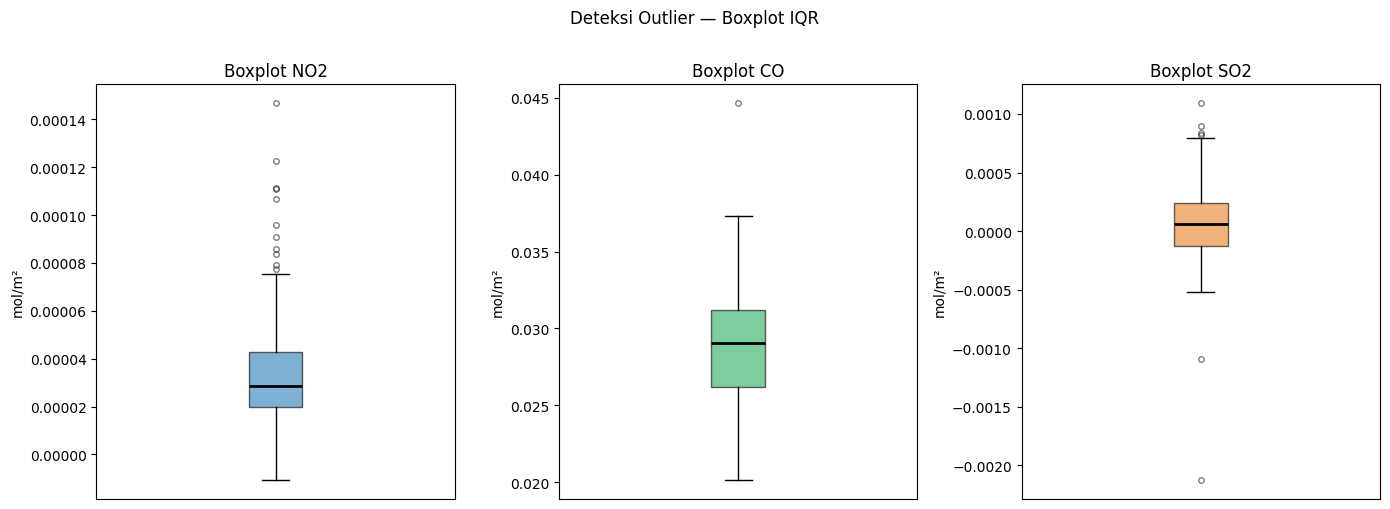

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, col, color in zip(axes, ["NO2", "CO", "SO2"], ["#2980b9", "#27ae60", "#e67e22"]):
    data = df[col].dropna()
    ax.boxplot(data, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6),
               medianprops=dict(color='black', linewidth=2),
               flierprops=dict(marker='o', markersize=4, color='red', alpha=0.5))
    ax.set_title(f"Boxplot {col}")
    ax.set_ylabel("mol/m²")
    ax.set_xticks([])

plt.suptitle("Deteksi Outlier — Boxplot IQR", y=1.01)
plt.tight_layout()
plt.show()

Tiga karakter berbeda terlihat dari boxplot ini. NO2 memiliki box yang kompak di rentang nilai rendah dengan 11 titik merah di atas whisker atas — outlier ini merepresentasikan hari-hari dengan lonjakan emisi NOx dari kendaraan berat, kapal, atau kondisi angin yang membawa polutan dari Surabaya/Gresik. CO memiliki distribusi paling simetris dengan hanya 1 outlier atas, menunjukkan sumber emisi yang relatif konsisten sepanjang tahun. SO2 menunjukkan pola paling tidak biasa: box-nya melebar ke bawah hingga nilai negatif, dengan titik merah di bawah whisker bawah — ini bukan outlier polusi nyata, melainkan noise retrieval TROPOMI yang konsisten menghasilkan nilai negatif di wilayah dengan konsentrasi SO2 latar belakang yang sangat rendah.

In [16]:
print("=== Baris dengan Nilai Negatif ===")
for col in ["NO2", "CO", "SO2"]:
    neg = df[df[col] < 0][["date", col]]
    if len(neg) > 0:
        print(f"\n{col} ({len(neg)} baris):")
        print(neg.to_string(index=False))
    else:
        print(f"\n{col}: tidak ada nilai negatif")

=== Baris dengan Nilai Negatif ===

NO2 (2 baris):
                     date           NO2
2026-04-05 00:00:00+00:00 -1.074266e-05
2026-08-22 00:00:00+00:00 -8.041791e-07

CO: tidak ada nilai negatif

SO2 (99 baris):
                     date       SO2
2025-08-26 00:00:00+00:00 -0.002125
2025-08-29 00:00:00+00:00 -0.000365
2025-08-31 00:00:00+00:00 -0.000478
2025-09-02 00:00:00+00:00 -0.000132
2025-09-04 00:00:00+00:00 -0.000093
2025-09-06 00:00:00+00:00 -0.000081
2025-09-09 00:00:00+00:00 -0.000297
2025-09-10 00:00:00+00:00 -0.000268
2025-09-13 00:00:00+00:00 -0.000001
2025-09-16 00:00:00+00:00 -0.000177
2025-09-19 00:00:00+00:00 -0.000293
2025-09-21 00:00:00+00:00 -0.000176
2025-09-24 00:00:00+00:00 -0.000123
2025-09-26 00:00:00+00:00 -0.000261
2025-09-27 00:00:00+00:00 -0.000202
2025-09-28 00:00:00+00:00 -0.000219
2025-10-02 00:00:00+00:00 -0.000368
2025-10-05 00:00:00+00:00 -0.000248
2025-10-06 00:00:00+00:00 -0.000142
2025-10-09 00:00:00+00:00 -0.000226
2025-10-11 00:00:00+00:00 -

SO2 memiliki 99 nilai negatif dengan minimum -0.002125 mol/m², sementara NO2 hanya 2 nilai negatif yang sangat kecil mendekati nol (-0.000011). CO tidak memiliki nilai negatif sama sekali. Nilai negatif SO2 yang banyak dan tersebar sepanjang tahun bukan anomali polusi — ini adalah karakteristik algoritmik. Retrieval SO2 di TROPOMI menggunakan metode diferensial yang bisa menghasilkan nilai negatif di wilayah dengan konsentrasi SO2 sangat rendah, di mana sinyal gas hampir tidak bisa dibedakan dari noise background. Nilai-nilai ini perlu di-clamp ke nol atau dikeluarkan sebelum tahap pemodelan.

In [17]:
print("=== Nilai Maksimum (Puncak Polutan) ===")
for col in ["NO2", "CO", "SO2"]:
    idx = df[col].idxmax()
    print(f"{col}  max: {df.loc[idx, col]:.6f}  pada: {df.loc[idx, 'date'].date()}")

=== Nilai Maksimum (Puncak Polutan) ===
NO2  max: 0.000147  pada: 2026-05-01
CO  max: 0.044651  pada: 2025-09-24
SO2  max: 0.001092  pada: 2026-05-15


Puncak NO2 terjadi pada 1 Mei 2026 (0.000147 mol/m²) dan puncak SO2 pada 15 Mei 2026 (0.001092 mol/m²) — keduanya di bulan yang sama. Mei adalah periode transisi dari musim hujan ke kemarau di Jawa Timur. Pada masa transisi ini, tutupan awan berkurang dan kondisi atmosfer menjadi lebih stabil sehingga polutan tidak tersebar vertikal dan terakumulasi di lapisan bawah troposfer lebih lama dari biasanya. Puncak CO justru terjadi lebih awal, 24 September 2025 (0.044651 mol/m²), yang bertepatan dengan puncak musim kemarau ketika pembakaran biomassa meningkat dan kondisi atmosfer kering memperlambat pengenceran polutan.

---

## 5. Visualisasi Time Series

Time series memperlihatkan perubahan konsentrasi polutan dari hari ke hari selama setahun penuh. Melalui visualisasi ini terlihat pola fluktuasi harian, lonjakan sesekali, dan perubahan musiman yang tidak bisa ditangkap hanya dari statistik deskriptif.

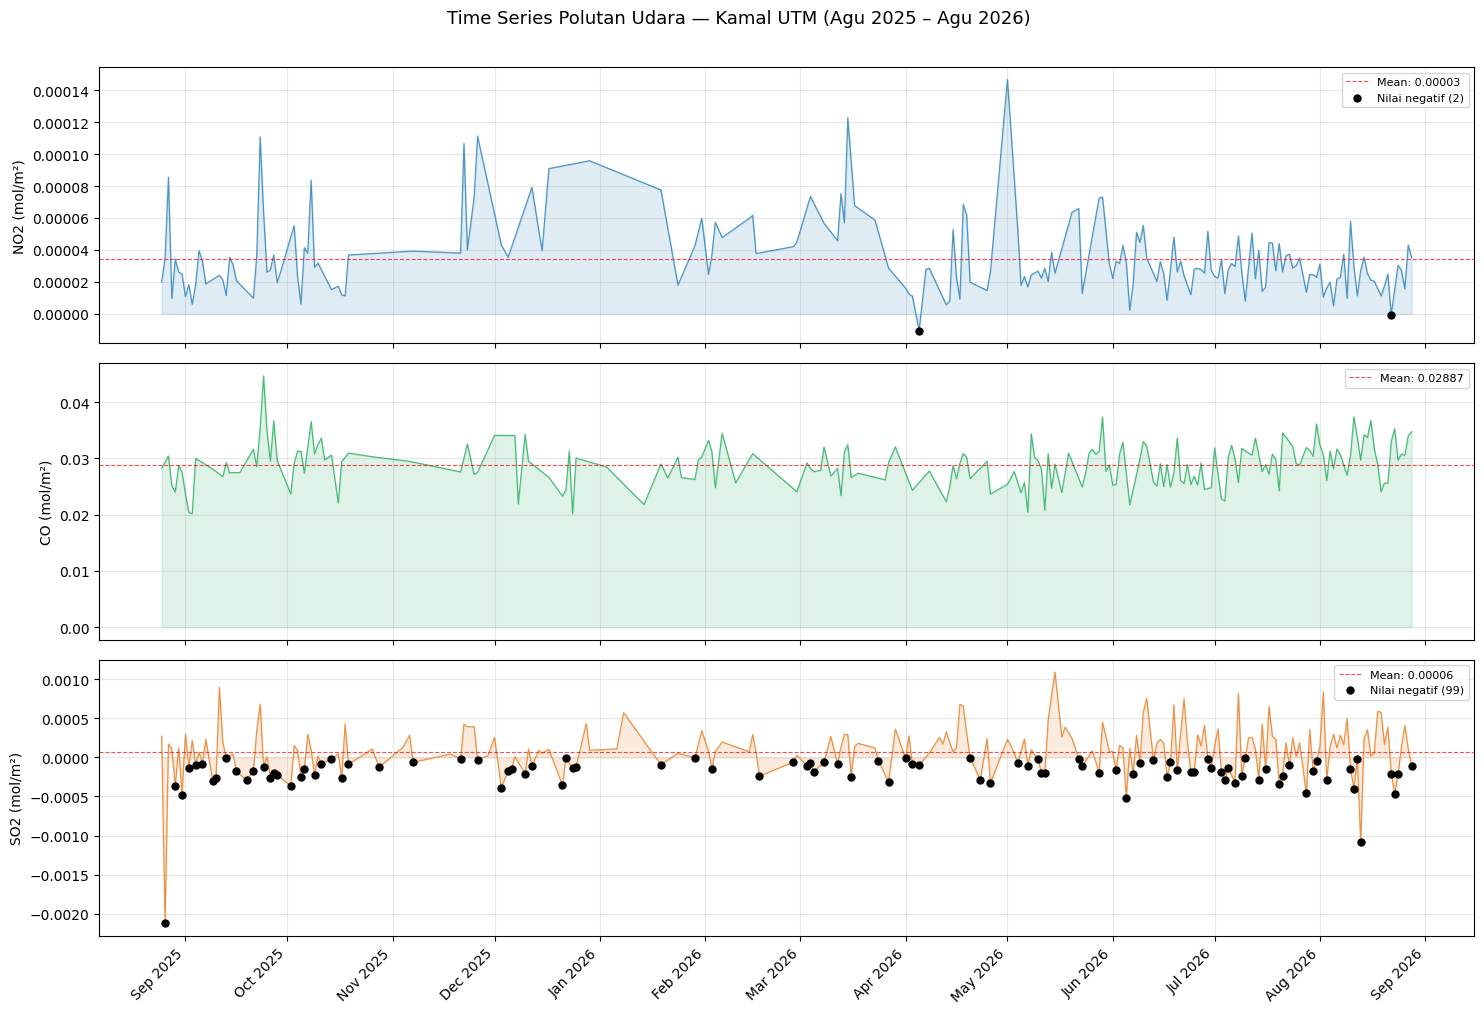

In [18]:
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

for ax, col, color in zip(axes, ["NO2", "CO", "SO2"], ["#2980b9", "#27ae60", "#e67e22"]):
    data_valid = df[df[col].notna()]
    ax.plot(data_valid["date"], data_valid[col],
            color=color, linewidth=0.9, alpha=0.8)
    ax.fill_between(data_valid["date"], data_valid[col], alpha=0.15, color=color)

    mean_val = data_valid[col].mean()
    ax.axhline(mean_val, color='red', linestyle='--',
               linewidth=0.8, alpha=0.7, label=f'Mean: {mean_val:.5f}')

    neg = df[df[col] < 0]
    if len(neg) > 0:
        ax.scatter(neg["date"], neg[col],
                   color='black', s=25, zorder=5, label=f'Nilai negatif ({len(neg)})')

    ax.set_ylabel(f"{col} (mol/m²)", fontsize=10)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())

plt.xticks(rotation=45, ha='right')
plt.suptitle("Time Series Polutan Udara — Kamal UTM (Agu 2025 – Agu 2026)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Tiga pola berbeda terlihat dari plot ini. NO2 menunjukkan fluktuasi harian yang tajam dengan beberapa lonjakan menonjol, terutama di sekitar Mei 2026 ketika nilainya hampir dua kali lipat rata-rata. Ini mencerminkan emisi yang tidak stabil dari kendaraan dan kapal yang aktivitasnya bervariasi tiap hari. CO bergerak lebih halus dan konsisten di atas garis mean hampir sepanjang periode, dengan satu lonjakan di September 2025 yang bertepatan dengan puncak kemarau. SO2 memperlihatkan titik-titik hitam (nilai negatif) tersebar hampir merata sepanjang tahun di bawah garis nol, memperkuat kesimpulan bahwa nilainya adalah noise sistemik dan bukan kejadian polusi nyata. Garis putus-putus merah (mean) membantu mengidentifikasi hari-hari yang konsentrasinya jauh di atas rata-rata tahunan.

C:\Users\ARIEL\AppData\Local\Temp\ipykernel_17080\2706875086.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["bulan"] = df["date"].dt.to_period("M")


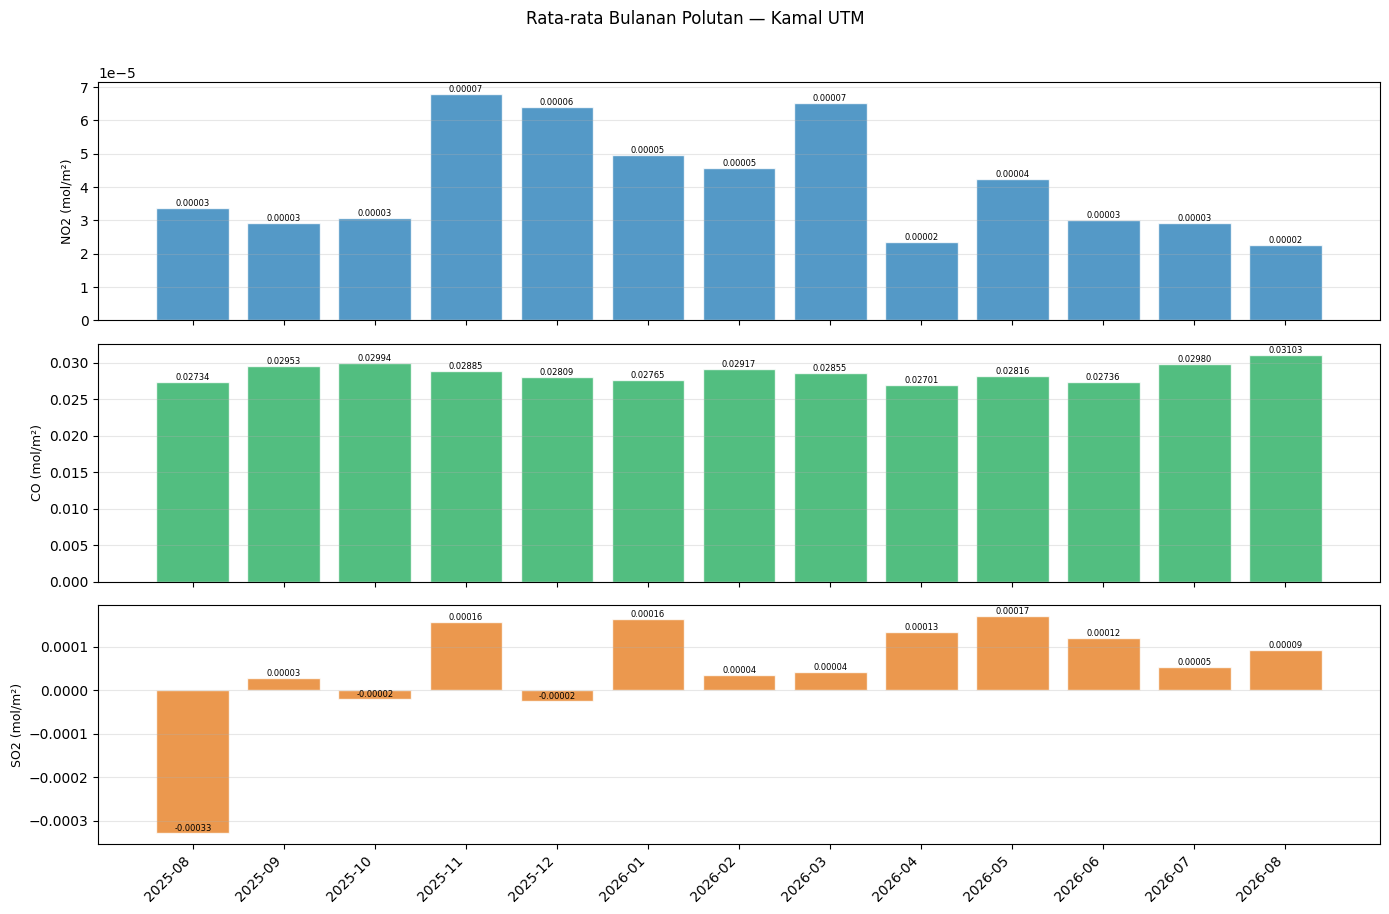

In [19]:
df["bulan"] = df["date"].dt.to_period("M")
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

for ax, col, color in zip(axes, ["NO2", "CO", "SO2"], ["#2980b9", "#27ae60", "#e67e22"]):
    bulanan = df.groupby("bulan")[col].mean()
    ax.bar(bulanan.index.astype(str), bulanan.values,
           color=color, alpha=0.8, edgecolor='white')
    ax.set_ylabel(f"{col} (mol/m²)", fontsize=9)
    ax.grid(True, axis='y', alpha=0.3)
    for i, v in enumerate(bulanan.values):
        if not pd.isna(v):
            ax.text(i, v, f"{v:.5f}", ha='center', va='bottom', fontsize=6)

plt.xticks(rotation=45, ha='right')
plt.suptitle("Rata-rata Bulanan Polutan — Kamal UTM", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

df.drop(columns=["bulan"], inplace=True)

Rata-rata bulanan memperhalus variasi harian sehingga pola musiman lebih terlihat. NO2 mencapai puncak di Mei 2026 lalu turun di bulan-bulan kemarau penuh (Juni-Agustus). CO relatif konsisten sepanjang tahun di kisaran 0.026-0.033 mol/m², dengan sedikit kenaikan di September-Oktober 2025 yang berkorelasi dengan puncak kemarau dan pembakaran biomassa. SO2 memiliki rata-rata bulanan yang sangat kecil dan beberapa bulan bernilai negatif akibat dominasi noise retrieval, menandakan konsentrasi SO2 nyata di wilayah Kamal memang sangat rendah dan berada di bawah sensitivitas deteksi TROPOMI untuk area sekecil bounding box yang digunakan.

---

## 6. Korelasi Antar Polutan

Korelasi mengukur kekuatan hubungan linear antara dua variabel. Nilai korelasi berkisar dari -1 (berlawanan arah sempurna) hingga 1 (searah sempurna). Pada konteks data polutan, korelasi positif tinggi antara dua gas mengindikasikan kemungkinan sumber emisi yang sama atau kondisi dispersi atmosfer yang memengaruhi keduanya secara bersamaan. Korelasi rendah menunjukkan sumber dan mekanisme yang berbeda.

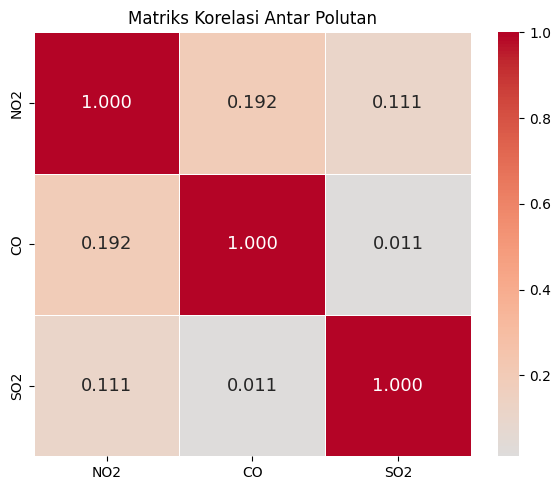


Nilai korelasi:
          NO2        CO       SO2
NO2  1.000000  0.192330  0.110931
CO   0.192330  1.000000  0.010997
SO2  0.110931  0.010997  1.000000


In [20]:
fig, ax = plt.subplots(figsize=(6, 5))

corr = df[["NO2", "CO", "SO2"]].corr()
sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm",
            center=0, ax=ax, linewidths=0.5, annot_kws={"size": 13})
ax.set_title("Matriks Korelasi Antar Polutan")
plt.tight_layout()
plt.show()

print("\nNilai korelasi:")
print(corr.to_string())

Korelasi NO2-CO sebesar 0.192 (lemah positif) menunjukkan bahwa kendaraan bermotor — yang menghasilkan keduanya — bukan satu-satunya faktor. NO2 juga dihasilkan kapal ferry dan industri, sementara CO dominan dari pembakaran tidak sempurna kendaraan tua dan sampah terbuka. Korelasi NO2-SO2 sebesar 0.111 juga lemah, mengindikasikan bahwa sumber SO2 utama (kapal ferry, angin industrial dari Gresik) berbeda dari sumber NO2 (kendaraan darat). CO-SO2 hampir tidak berkorelasi (0.011), konsisten dengan sumber yang sepenuhnya berbeda. Secara keseluruhan, tidak ada pasangan polutan yang berkorelasi kuat, menunjukkan bahwa wilayah Kamal-UTM dipengaruhi oleh beberapa sumber emisi dengan karakter berbeda yang bekerja secara independen.

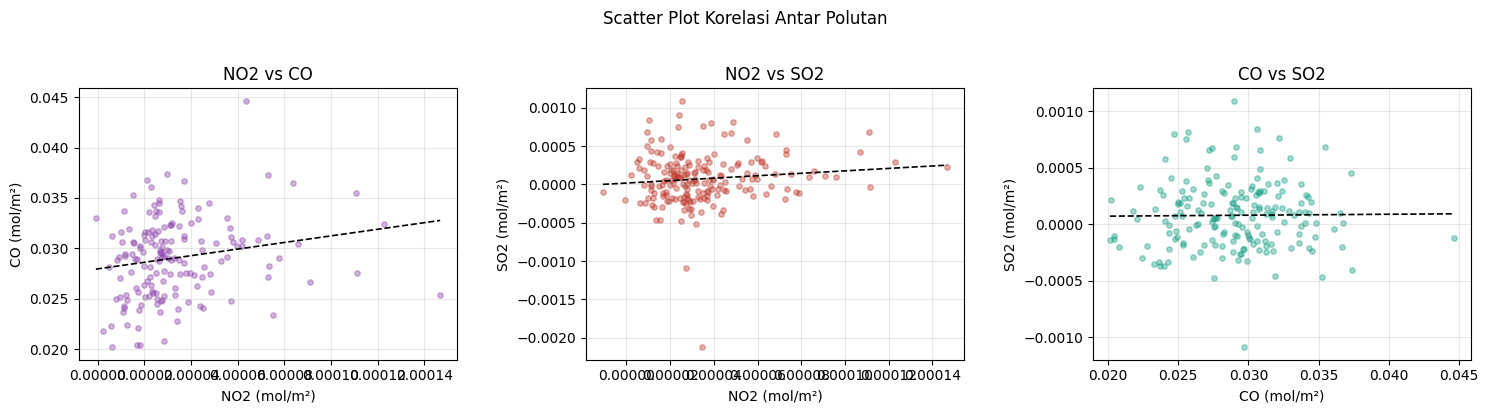

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

pairs       = [("NO2", "CO"), ("NO2", "SO2"), ("CO", "SO2")]
colors_pair = ["#8e44ad", "#c0392b", "#16a085"]

for ax, (x, y), color in zip(axes, pairs, colors_pair):
    d = df[[x, y]].dropna()
    ax.scatter(d[x], d[y], color=color, alpha=0.4, s=15)
    z = np.polyfit(d[x], d[y], 1)
    p = np.poly1d(z)
    xline = np.linspace(d[x].min(), d[x].max(), 100)
    ax.plot(xline, p(xline), color='black', linewidth=1.2, linestyle='--')
    ax.set_xlabel(f"{x} (mol/m²)")
    ax.set_ylabel(f"{y} (mol/m²)")
    ax.set_title(f"{x} vs {y}")
    ax.grid(True, alpha=0.3)

plt.suptitle("Scatter Plot Korelasi Antar Polutan", y=1.02)
plt.tight_layout()
plt.show()

Scatter plot memvisualisasikan hubungan antar polutan secara lebih intuitif dibanding angka korelasi. Pasangan NO2-CO memperlihatkan sebaran titik yang sedikit mengikuti garis regresi dengan lereng positif tipis — ada tendensi hari dengan NO2 tinggi juga memiliki CO sedikit lebih tinggi, tapi polanya sangat bervariasi. Pasangan NO2-SO2 dan CO-SO2 memperlihatkan sebaran yang jauh lebih acak, dengan banyak titik di bawah sumbu Y (nilai SO2 negatif) yang sebetulnya bukan data polutan nyata. Garis regresi pada ketiga scatter plot mendekati horizontal, mengkonfirmasi korelasi yang lemah.~cle